# B. Green Space Analysis

This notebook examines the spatial distribution of open space and green space availability across SA2 areas in Greater Melbourne. Two indicators are analysed:

- Open space coverage (%)
- Green space per capita (m²/person)

In [8]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [7]:
sa2 = sa2.to_crs(7855)
open_space = open_space.to_crs(7855)

overlay = gpd.overlay(
    open_space,
    sa2[["sa2_code", "sa2_name", "geometry"]],
    how="intersection"
)

overlay["open_space_area_m2"] = overlay.geometry.area

summary = (
    overlay
    .groupby("sa2_code")["open_space_area_m2"]
    .sum()
    .reset_index()
)

melb = sa2.merge(summary, on="sa2_code", how="left")

melb["open_space_area_m2"] = melb["open_space_area_m2"].fillna(0)

melb["open_space_coverage_pct"] = (
    melb["open_space_area_m2"] / melb["area_m2"] * 100
)

melb[["sa2_name", "open_space_coverage_pct"]].head()

,sa2_name,open_space_coverage_pct
0,Hoppers Crossing - South,11.790865
1,Werribee - South,61.657572
2,Werribee - East,21.359952
3,Hoppers Crossing - North,9.536077
4,Tarneit - South,14.460548


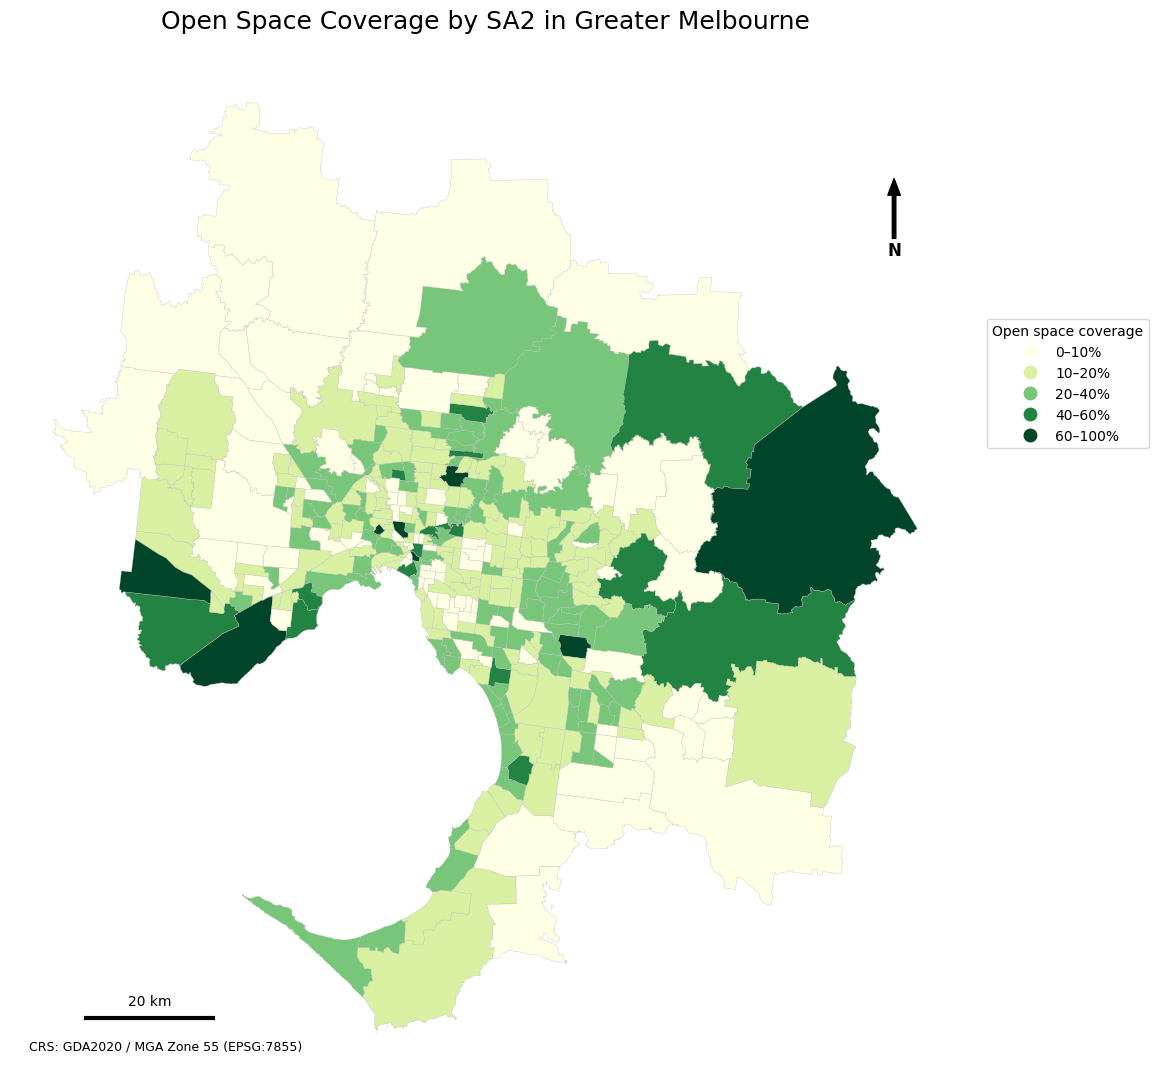

In [14]:
bins = [0, 10, 20, 40, 60, 100]
labels = ["0–10%", "10–20%", "20–40%", "40–60%", "60–100%"]

melb["coverage_class"] = pd.cut(
    melb["open_space_coverage_pct"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

fig, ax = plt.subplots(figsize=(13, 11))

melb.plot(
    column="coverage_class",
    cmap="YlGn",
    linewidth=0.25,
    edgecolor="#bdbdbd",
    legend=True,
    categorical=True,
    ax=ax,
    legend_kwds={
        "title": "Open space coverage",
        "loc": "upper left",
        "bbox_to_anchor": (1.02, 0.75),
        "frameon": True
    }
)

ax.set_title(
    "Open Space Coverage by SA2 in Greater Melbourne",
    fontsize=18,
    pad=20
)

ax.axis("off")

# North arrow, smaller and cleaner
ax.annotate(
    "N",
    xy=(0.93, 0.88),
    xytext=(0.93, 0.81),
    xycoords="axes fraction",
    arrowprops=dict(facecolor="black", edgecolor="black", width=2.5, headwidth=9),
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold"
)

# Scale bar
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

scale_length = 20000
x_start = x_min + (x_max - x_min) * 0.08
y_start = y_min + (y_max - y_min) * 0.06

ax.plot(
    [x_start, x_start + scale_length],
    [y_start, y_start],
    color="black",
    linewidth=3
)

ax.text(
    x_start + scale_length / 2,
    y_start + (y_max - y_min) * 0.012,
    "20 km",
    ha="center",
    fontsize=10
)

# CRS note, moved below map
fig.text(
    0.12,
    0.04,
    "CRS: GDA2020 / MGA Zone 55 (EPSG:7855)",
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    "../outputs/maps/open_space_coverage_classified_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

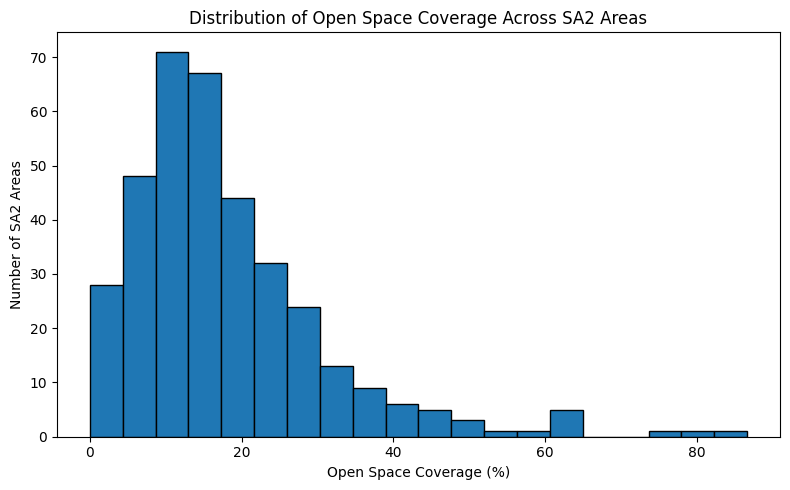

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(
    melb["open_space_coverage_pct"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("Open Space Coverage (%)")
plt.ylabel("Number of SA2 Areas")
plt.title("Distribution of Open Space Coverage Across SA2 Areas")

plt.tight_layout()

plt.savefig(
    "../outputs/maps/open_space_coverage_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
summary_stats = melb["open_space_coverage_pct"].describe()
summary_stats

count    360.000000
mean      17.962000
std       13.133685
min        0.000000
25%        9.717249
50%       14.855860
75%       22.540300
max       86.601949
Name: open_space_coverage_pct, dtype: float64

In [12]:
top10 = (
    melb
    .sort_values("open_space_coverage_pct", ascending=False)
    [["sa2_name", "open_space_coverage_pct"]]
    .head(10)
)

top10

,sa2_name,open_space_coverage_pct
12,Manor Lakes - Quandong,86.601949
269,Royal Botanic Gardens Victoria,81.410302
213,Flemington Racecourse,74.079449
180,Yarra Valley,64.781912
217,Parkville,62.225407
1,Werribee - South,61.657572
227,Kingsbury,61.616537
339,Endeavour Hills - North,61.567997
199,Mount Dandenong - Olinda,58.446738
203,Clifton Hill - Alphington,52.123445


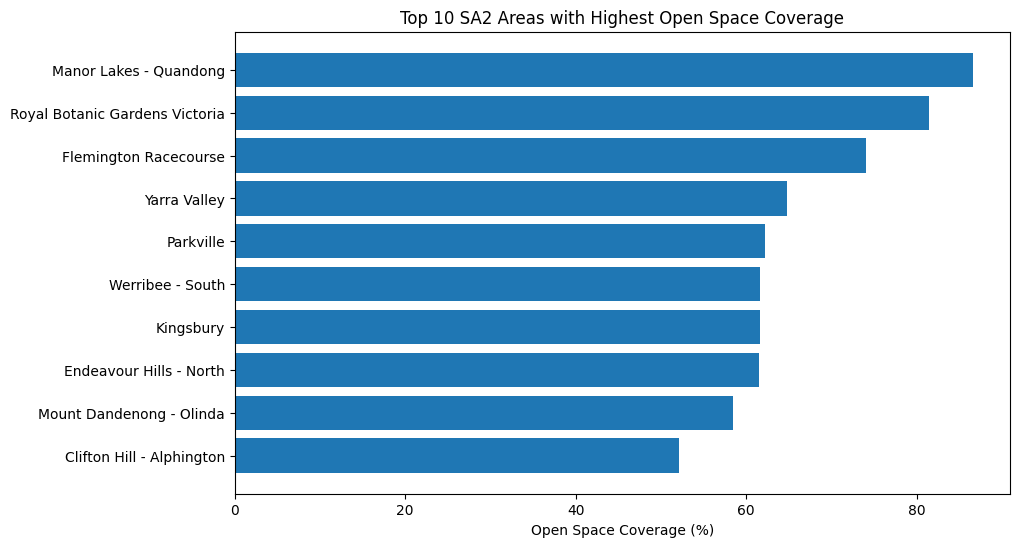

In [16]:
top10 = (
    melb
    .sort_values("open_space_coverage_pct", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    top10["sa2_name"],
    top10["open_space_coverage_pct"]
)

plt.xlabel("Open Space Coverage (%)")
plt.title("Top 10 SA2 Areas with Highest Open Space Coverage")

plt.gca().invert_yaxis()

plt.show()

In [13]:
bottom10 = (
    melb
    .sort_values("open_space_coverage_pct", ascending=True)
    [["sa2_name", "open_space_coverage_pct"]]
    .head(10)
)

bottom10

,sa2_name,open_space_coverage_pct
252,Moorabbin Airport,0.000000
66,Riddells Creek,0.000000
83,Essendon Airport,0.000000
68,Romsey,0.001288
65,Kinglake,0.001875
31,Gisborne,0.002157
27,Bacchus Marsh,0.002957
18,Tarneit - North,0.080914
321,Clyde North - South,0.208715
33,Diggers Rest,0.362264


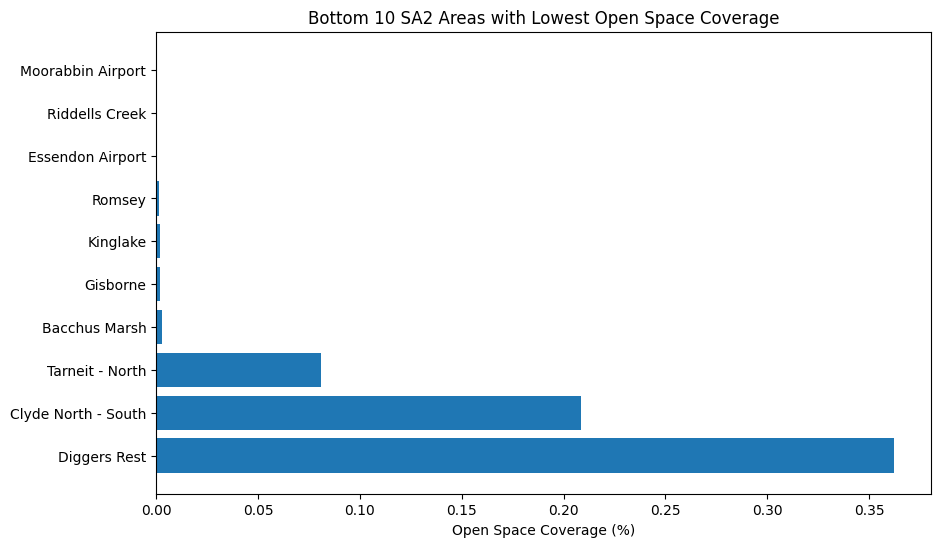

In [17]:
bottom10 = (
    melb
    .sort_values("open_space_coverage_pct")
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    bottom10["sa2_name"],
    bottom10["open_space_coverage_pct"]
)

plt.xlabel("Open Space Coverage (%)")
plt.title("Bottom 10 SA2 Areas with Lowest Open Space Coverage")

plt.gca().invert_yaxis()

plt.show()

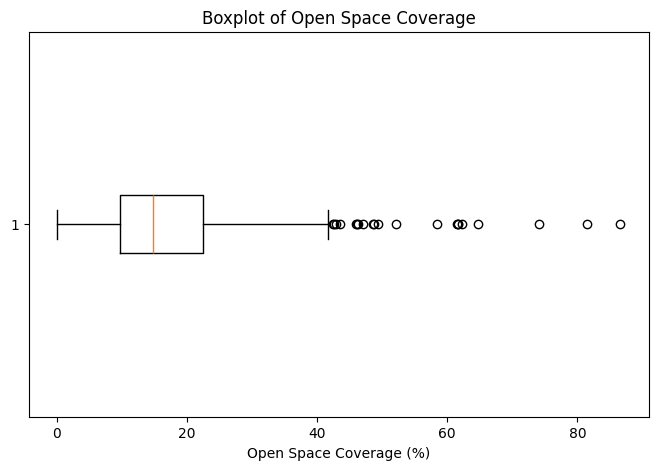

In [15]:
plt.figure(figsize=(8,5))

plt.boxplot(
    melb["open_space_coverage_pct"],
    vert=False
)

plt.xlabel("Open Space Coverage (%)")
plt.title("Boxplot of Open Space Coverage")

plt.show()

In [18]:
pop = pd.read_csv("../data/raw/census/2021Census_G01_VIC_SA2.csv")

print(pop.columns.tolist())

['SA2_CODE_2021', 'Tot_P_M', 'Tot_P_F', 'Tot_P_P', 'Age_0_4_yr_M', 'Age_0_4_yr_F', 'Age_0_4_yr_P', 'Age_5_14_yr_M', 'Age_5_14_yr_F', 'Age_5_14_yr_P', 'Age_15_19_yr_M', 'Age_15_19_yr_F', 'Age_15_19_yr_P', 'Age_20_24_yr_M', 'Age_20_24_yr_F', 'Age_20_24_yr_P', 'Age_25_34_yr_M', 'Age_25_34_yr_F', 'Age_25_34_yr_P', 'Age_35_44_yr_M', 'Age_35_44_yr_F', 'Age_35_44_yr_P', 'Age_45_54_yr_M', 'Age_45_54_yr_F', 'Age_45_54_yr_P', 'Age_55_64_yr_M', 'Age_55_64_yr_F', 'Age_55_64_yr_P', 'Age_65_74_yr_M', 'Age_65_74_yr_F', 'Age_65_74_yr_P', 'Age_75_84_yr_M', 'Age_75_84_yr_F', 'Age_75_84_yr_P', 'Age_85ov_M', 'Age_85ov_F', 'Age_85ov_P', 'Counted_Census_Night_home_M', 'Counted_Census_Night_home_F', 'Counted_Census_Night_home_P', 'Count_Census_Nt_Ewhere_Aust_M', 'Count_Census_Nt_Ewhere_Aust_F', 'Count_Census_Nt_Ewhere_Aust_P', 'Indigenous_psns_Aboriginal_M', 'Indigenous_psns_Aboriginal_F', 'Indigenous_psns_Aboriginal_P', 'Indig_psns_Torres_Strait_Is_M', 'Indig_psns_Torres_Strait_Is_F', 'Indig_psns_Torres_Str

In [20]:
print(melb["sa2_code"].dtype)
print(pop["SA2_CODE_2021"].dtype)

str
int64


In [21]:
pop["SA2_CODE_2021"] = pop["SA2_CODE_2021"].astype(str)

melb = melb.merge(
    pop[["SA2_CODE_2021", "Tot_P_P"]],
    left_on="sa2_code",
    right_on="SA2_CODE_2021",
    how="left"
)

melb[["sa2_name", "Tot_P_P"]].head()

,sa2_name,Tot_P_P
0,Hoppers Crossing - South,18772
1,Werribee - South,16810
2,Werribee - East,19010
3,Hoppers Crossing - North,18446
4,Tarneit - South,11182


In [22]:
melb["green_space_per_capita_m2"] = (
    melb["open_space_area_m2"] / melb["Tot_P_P"]
)

melb[["sa2_name", "green_space_per_capita_m2"]].head()

,sa2_name,green_space_per_capita_m2
0,Hoppers Crossing - South,44.045596
1,Werribee - South,4183.676040
2,Werribee - East,87.176370
3,Hoppers Crossing - North,56.430092
4,Tarneit - South,40.491106


In [25]:
melb["sa2_code"] = melb["sa2_code"].astype(str).str.strip()
pop["SA2_CODE_2021"] = pop["SA2_CODE_2021"].astype(str).str.strip()

melb = melb.drop(columns=["SA2_CODE_2021", "Tot_P_P"], errors="ignore")

melb = melb.merge(
    pop[["SA2_CODE_2021", "Tot_P_P"]],
    left_on="sa2_code",
    right_on="SA2_CODE_2021",
    how="left"
)

melb["green_space_per_capita_m2"] = (
    melb["open_space_area_m2"] / melb["Tot_P_P"]
)

melb[["sa2_name", "Tot_P_P", "green_space_per_capita_m2"]].head()

,sa2_name,Tot_P_P,green_space_per_capita_m2
0,Hoppers Crossing - South,18772,44.045596
1,Werribee - South,16810,4183.676040
2,Werribee - East,19010,87.176370
3,Hoppers Crossing - North,18446,56.430092
4,Tarneit - South,11182,40.491106


In [27]:
print(melb["Tot_P_P"].isna().sum())
print(melb["green_space_per_capita_m2"].isna().sum())
print(melb[["sa2_code", "sa2_name", "Tot_P_P", "open_space_area_m2", "green_space_per_capita_m2"]].head(10))

0
0
    sa2_code                  sa2_name  Tot_P_P  open_space_area_m2  \
0  213051362  Hoppers Crossing - South    18772        8.268239e+05   
1  213051368          Werribee - South    16810        7.032759e+07   
2  213051467           Werribee - East    19010        1.657223e+06   
3  213051361  Hoppers Crossing - North    18446        1.040909e+06   
4  213051585           Tarneit - South    11182        4.527715e+05   
5  213051464         Point Cook - East    19274        9.280699e+06   
6  213051466        Point Cook - South    19091        7.128177e+05   
7  213051468           Werribee - West    22341        5.555488e+07   
8  213051590      Wyndham Vale - South    13546        6.762206e+05   
9  213051581   Point Cook - North West     9565        4.324937e+05   

   green_space_per_capita_m2  
0                  44.045596  
1                4183.676040  
2                  87.176370  
3                  56.430092  
4                  40.491106  
5                 481.513898

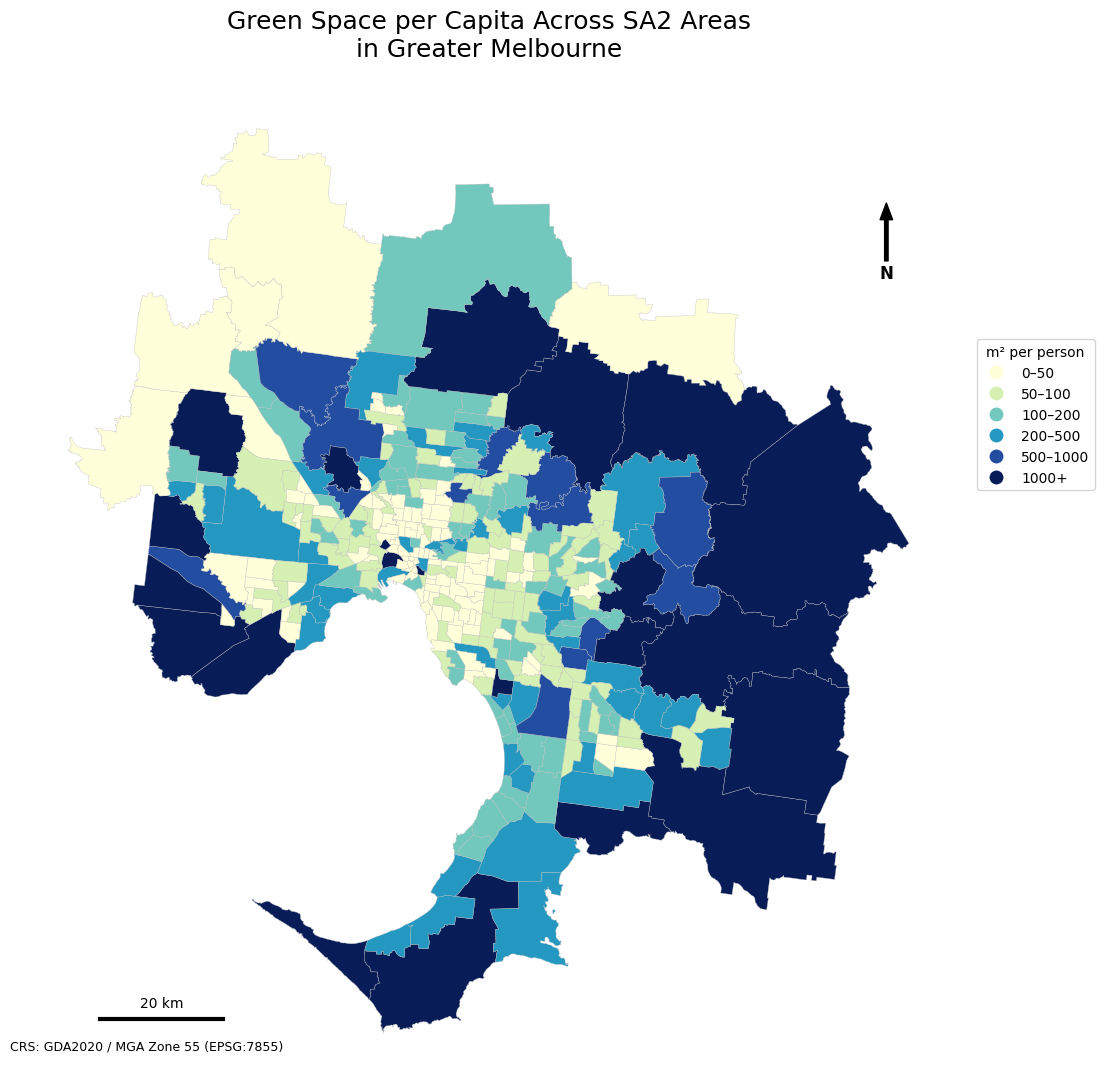

In [31]:
# Classified Green Space per Capita Map

bins = [
    0,
    50,
    100,
    200,
    500,
    1000,
    melb["green_space_per_capita_m2"].max()
]

labels = [
    "0–50",
    "50–100",
    "100–200",
    "200–500",
    "500–1000",
    "1000+"
]

melb["per_capita_class"] = pd.cut(
    melb["green_space_per_capita_m2"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

fig, ax = plt.subplots(figsize=(13, 11))

melb.plot(
    column="per_capita_class",
    cmap="YlGnBu",
    categorical=True,
    legend=True,
    linewidth=0.25,
    edgecolor="#bdbdbd",
    ax=ax,
    legend_kwds={
        "title": "m² per person",
        "loc": "upper left",
        "bbox_to_anchor": (1.02, 0.75),
        "frameon": True
    }
)

ax.set_title(
    "Green Space per Capita Across SA2 Areas\nin Greater Melbourne",
    fontsize=18,
    pad=20
)

ax.axis("off")

# North arrow
ax.annotate(
    "N",
    xy=(0.93, 0.88),
    xytext=(0.93, 0.81),
    xycoords="axes fraction",
    arrowprops=dict(
        facecolor="black",
        edgecolor="black",
        width=2.5,
        headwidth=9
    ),
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold"
)

# Scale bar
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

scale_length = 20000  # 20 km
x_start = x_min + (x_max - x_min) * 0.08
y_start = y_min + (y_max - y_min) * 0.06

ax.plot(
    [x_start, x_start + scale_length],
    [y_start, y_start],
    color="black",
    linewidth=3
)

ax.text(
    x_start + scale_length / 2,
    y_start + (y_max - y_min) * 0.012,
    "20 km",
    ha="center",
    fontsize=10
)

# CRS note
fig.text(
    0.12,
    0.04,
    "CRS: GDA2020 / MGA Zone 55 (EPSG:7855)",
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    "../outputs/maps/green_space_per_capita_classified_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
top10_pc = melb.sort_values(
    "green_space_per_capita_m2",
    ascending=False
)[["sa2_name", "green_space_per_capita_m2"]].head(10)

top10_pc

,sa2_name,green_space_per_capita_m2
269,Royal Botanic Gardens Victoria,inf
130,West Melbourne - Industrial,inf
246,Braeside,1.351633e+05
180,Yarra Valley,2.812845e+04
50,Panton Hill - St Andrews,1.791496e+04
213,Flemington Racecourse,1.644474e+04
179,Healesville - Yarra Glen,1.207705e+04
304,Emerald - Cockatoo,9.392123e+03
58,Whittlesea,8.533090e+03
70,Melbourne Airport,7.781106e+03


In [33]:
bottom10_pc = melb.sort_values(
    "green_space_per_capita_m2",
    ascending=True
)[["sa2_name", "green_space_per_capita_m2"]].head(10)

bottom10_pc

,sa2_name,green_space_per_capita_m2
66,Riddells Creek,0.000000
252,Moorabbin Airport,0.000000
83,Essendon Airport,0.000000
27,Bacchus Marsh,0.234977
31,Gisborne,0.320284
68,Romsey,0.747379
271,Melbourne CBD - East,1.033957
65,Kinglake,1.424847
18,Tarneit - North,1.613201
165,Seddon - Kingsville,2.379882


In [6]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sa2 = gpd.read_file("../data/processed/sa2_master_base.gpkg")
open_space = gpd.read_file("../data/raw/open_space/open_space_melbourne.gpkg")

print(sa2.columns.tolist())
print(open_space.columns.tolist())

['sa2_code', 'sa2_name', 'area_m2', 'area_km2', 'geometry']
['LGA', 'VM_PARCEL_', 'VM_PARCE_1', 'DATA_SOURC', 'OS_CATEGOR', 'OS_CATEG_2', 'OWNER_TYPE', 'PARK_NAME', 'OS_STATUS', 'OS_ACCESS', 'MANAGER_TY', 'HA', 'SUBREGION', 'VEAC_ID', 'WATER_BODY', 'OS_TYPE', 'COASTAL', 'MANAGER_NA', 'OWNER_NAME', 'Image_URL', 'VPA_ID', 'geometry']
